In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.tree import DecisionTreeClassifier

import koreanize_matplotlib
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('../Data/당뇨_전처리.csv')
df

,임신횟수,혈당,혈압,피부두께,인슐린,BMI,가족력지표,나이,당뇨
0,6,148.0,72.0,35.0,159.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,95.0,26.6,0.351,31,0
2,8,183.0,64.0,32.0,159.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
712,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0
713,2,122.0,70.0,27.0,95.0,36.8,0.340,27,0
714,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0
715,1,126.0,60.0,32.0,159.0,30.1,0.349,47,1


In [3]:
# 앱으로 만들어야 하므로 유저가 쉽게 입력 할 수 있는 것들만 피쳐로 선정해서 해보는 것으로 함
df = df[['BMI','나이','가족력지표','혈당','피부두께','당뇨']]
data = df.iloc[:,:-1]
target = df.iloc[:,-1]
data['Waist_Risk_Factor'] = (data['BMI'] ** 1.2) / 10
data['Abdominal_Glucose_Risk'] = (data['혈당'] * data['Waist_Risk_Factor']) / 100
data['가족력로그'] = np.log10(data['가족력지표'])
data.drop(['Waist_Risk_Factor','가족력지표'],axis = 1,inplace=True)
train_data, test_data, train_target, test_target = train_test_split(
    data,
    target,
    random_state=42,
    test_size= 0.2,
    stratify=df.iloc[:,-1]
)

from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
ss.fit(train_data)
train_scaled = ss.transform(train_data)
test_scaled = ss.transform(test_data)
x_train_data, x_valid_data, y_train_target, y_valid_target = train_test_split(
    train_scaled,
    train_target,
    random_state=42,
    test_size= 0.2,
    stratify=train_target
)


In [4]:
data

,BMI,나이,혈당,피부두께,Abdominal_Glucose_Risk,가족력로그
0,33.6,50,148.0,35.0,10.043125,-0.202732
1,26.6,31,85.0,29.0,4.357896,-0.454693
2,23.3,32,183.0,32.0,8.003468,-0.172631
3,28.1,21,89.0,23.0,4.873462,-0.777284
4,43.1,33,137.0,35.0,12.534104,0.359456
...,...,...,...,...,...,...
712,32.9,63,101.0,48.0,6.682769,-0.767004
713,36.8,27,122.0,27.0,9.233731,-0.468521
714,26.2,30,121.0,23.0,6.091818,-0.610834
715,30.1,47,126.0,32.0,7.492907,-0.457175


In [ ]:
from sklearn.linear_model import LinearRegression

# 1. 혈당을 타겟으로 하는 회귀 모델 생성
# (혈당이 0인 결측치는 제외하고 학습)
df_glc = df[df['혈당'] > 0].copy()

X_glc = df_glc[['BMI', '나이']]
y_glc = df_glc['혈당']

glc_model = LinearRegression()
glc_model.fit(X_glc, y_glc)

# 2. 계수 추출
bmi_coef = glc_model.coef_[0]
age_coef = glc_model.coef_[1]
intercept = glc_model.intercept_

def predict_glucose(bmi, age):
    # 통상적으로 BMI가 1 오를 때 혈당은 약 0.8~1.2 정도 오르는 경향이 있습니다.
    est_glc = (bmi_coef * bmi) + (age_coef * age) + intercept
    return round(est_glc, 2)

# 테스트
print(f"유저의 예상 평상시 혈당: {predict_glucose(25.4, 41)} mg/dL")

BMI 28, 40세 유저의 예상 평상시 혈당: 118.47 mg/dL


In [6]:
print(bmi_coef, age_coef, intercept)

0.9806825594100111 0.6817116341473727 65.60660909858092


In [7]:
def calculate_pedigree_score(has_parents=False, has_siblings=False, has_grandparents=False):
    """
    유저의 체크 항목을 기반으로 당뇨 가족력지표(Pedigree Function)를 계산합니다.
    """
    # 1. 기본 점수 (가족력이 없는 경우의 최소치)
    score = 0.08
    
    # 2. 직계 가족 가중치 합산
    if has_parents:
        score += 0.35 
        
    if has_siblings:
        score += 0.25  # 형제/자매 중 있는 경우
        
    if has_grandparents:
        score += 0.15  # 조부모님 중 있는 경우
        
    # np.log1p는 ln(1 + x)를 계산하여 값의 왜곡을 줄여줍니다.
    log_score = np.log1p(score)
    
    return round(log_score, 4)

user_score = calculate_pedigree_score(has_parents=True, has_siblings=False, has_grandparents=True)

print(f"유저의 최종 입력용 가족력 점수: {user_score}")

유저의 최종 입력용 가족력 점수: 0.4574


> 가족력지표는 앱에서 체크를 받아 자동 대응하는 것으로 함

In [ ]:

df_skin = df[df['피부두께'] > 0].copy()

X_skin = df_skin[['BMI', '나이']]
y_skin = df_skin['피부두께']

skin_model = LinearRegression()
skin_model.fit(X_skin, y_skin)

# 2. 계수 추출
bmi_coef = skin_model.coef_[0]
age_coef = skin_model.coef_[1]
intercept = skin_model.intercept_

def prodict_skin(bmi, age):
    # 통상적으로 BMI가 1 오를 때 혈당은 약 0.8~1.2 정도 오르는 경향이 있습니다.
    est_skin = (bmi_coef * bmi) + (age_coef * age) + intercept
    return round(est_skin, 2)

# 테스트
print(f"유저의 예상 피부두께: {prodict_skin(22.6, 31)}")

BMI 28, 40세 유저의 예상 피부두께: 21.64


In [9]:
print(bmi_coef, age_coef, intercept)

0.7320350425409223 0.07081157992000305 2.8965508352678846


> 피부 두께는 BMI를 이용하여 선형회귀를 이용하여 예측하는 것으로 함

In [7]:
# 아래의 파라미터는 여기저기서 써보라고 했기에 써봤는데 확실히 점수 차이가 있음
depth = 4 
msl = 3 
mss = 3

estimator_range = range(5, 201, 5)
cv_scores = []

for r in estimator_range:
    rf = RandomForestClassifier(n_estimators=r, max_depth=depth, n_jobs=-1, random_state=42, min_samples_leaf=msl, min_samples_split=mss)
    
    scores = cross_val_score(rf, x_train_data, y_train_target, cv=6, scoring='accuracy', n_jobs=-1)
    cv_scores.append(scores.mean())

best_n = list(estimator_range)[np.argmax(cv_scores)]
print(f"최적의 n_estimators: {best_n}")
print(f"최고 교차 검증 점수: {max(cv_scores):.4f}")

final_rf = RandomForestClassifier(n_estimators=best_n, max_depth=depth, n_jobs=-1, random_state=42,min_samples_leaf=msl, min_samples_split=mss)
final_rf.fit(train_scaled, train_target)

print("-" * 30)
print(f"최종 Train 점수: {final_rf.score(train_scaled, train_target):.4f}")
print(f"최종 Test 점수: {final_rf.score(test_scaled, test_target):.4f}")


최적의 n_estimators: 185
최고 교차 검증 점수: 0.8210
------------------------------
최종 Train 점수: 0.8796
최종 Test 점수: 0.8264


In [10]:
pred = final_rf.predict(test_scaled)
accuracy = metrics.accuracy_score(test_target, pred)
precision = metrics.precision_score(test_target, pred)
recall = metrics.recall_score(test_target, pred)
f1 = metrics.f1_score(test_target, pred)
cm = metrics.confusion_matrix(test_target, pred)

print(f"정확도: {accuracy:.4f}")
print(f"정밀도: {precision:.4f}")
print(f"재현율: {recall:.4f}")
print(f"F1  : {f1:.4f}")
print(f"혼동 행렬 : {cm}")

정확도: 0.8264
정밀도: 0.7447
재현율: 0.7292
F1  : 0.7368
혼동 행렬 : [[84 12]
 [13 35]]


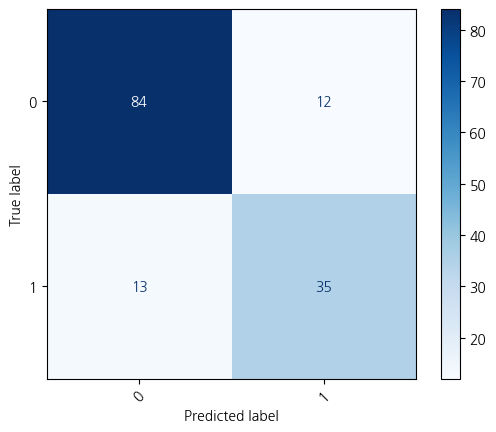

In [11]:


metrics.confusion_matrix(test_target, pred)
disp = metrics.ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=sorted(test_target.unique())
)
disp.plot(
    cmap=plt.cm.Blues,
    xticks_rotation=45
)

plt.show()

In [8]:
import joblib

joblib.dump(final_rf, 'diabetes_model.h5')
joblib.dump(ss, 'scaler.h5') # 스케일링을 사용했다면 필수

['scaler.h5']

In [13]:
lmm = joblib.load('diabetes_model.h5')
lmm

RandomForestClassifier(max_depth=4, min_samples_leaf=3, min_samples_split=3,
                       n_estimators=90, n_jobs=-1, random_state=42)